              precision    recall  f1-score   support

     healing       0.12      0.33      0.18         3
 Not-healing       0.75      0.46      0.57        13

   micro avg       0.44      0.44      0.44        16
   macro avg       0.44      0.40      0.38        16
weighted avg       0.63      0.44      0.50        16
 samples avg       0.44      0.44      0.44        16



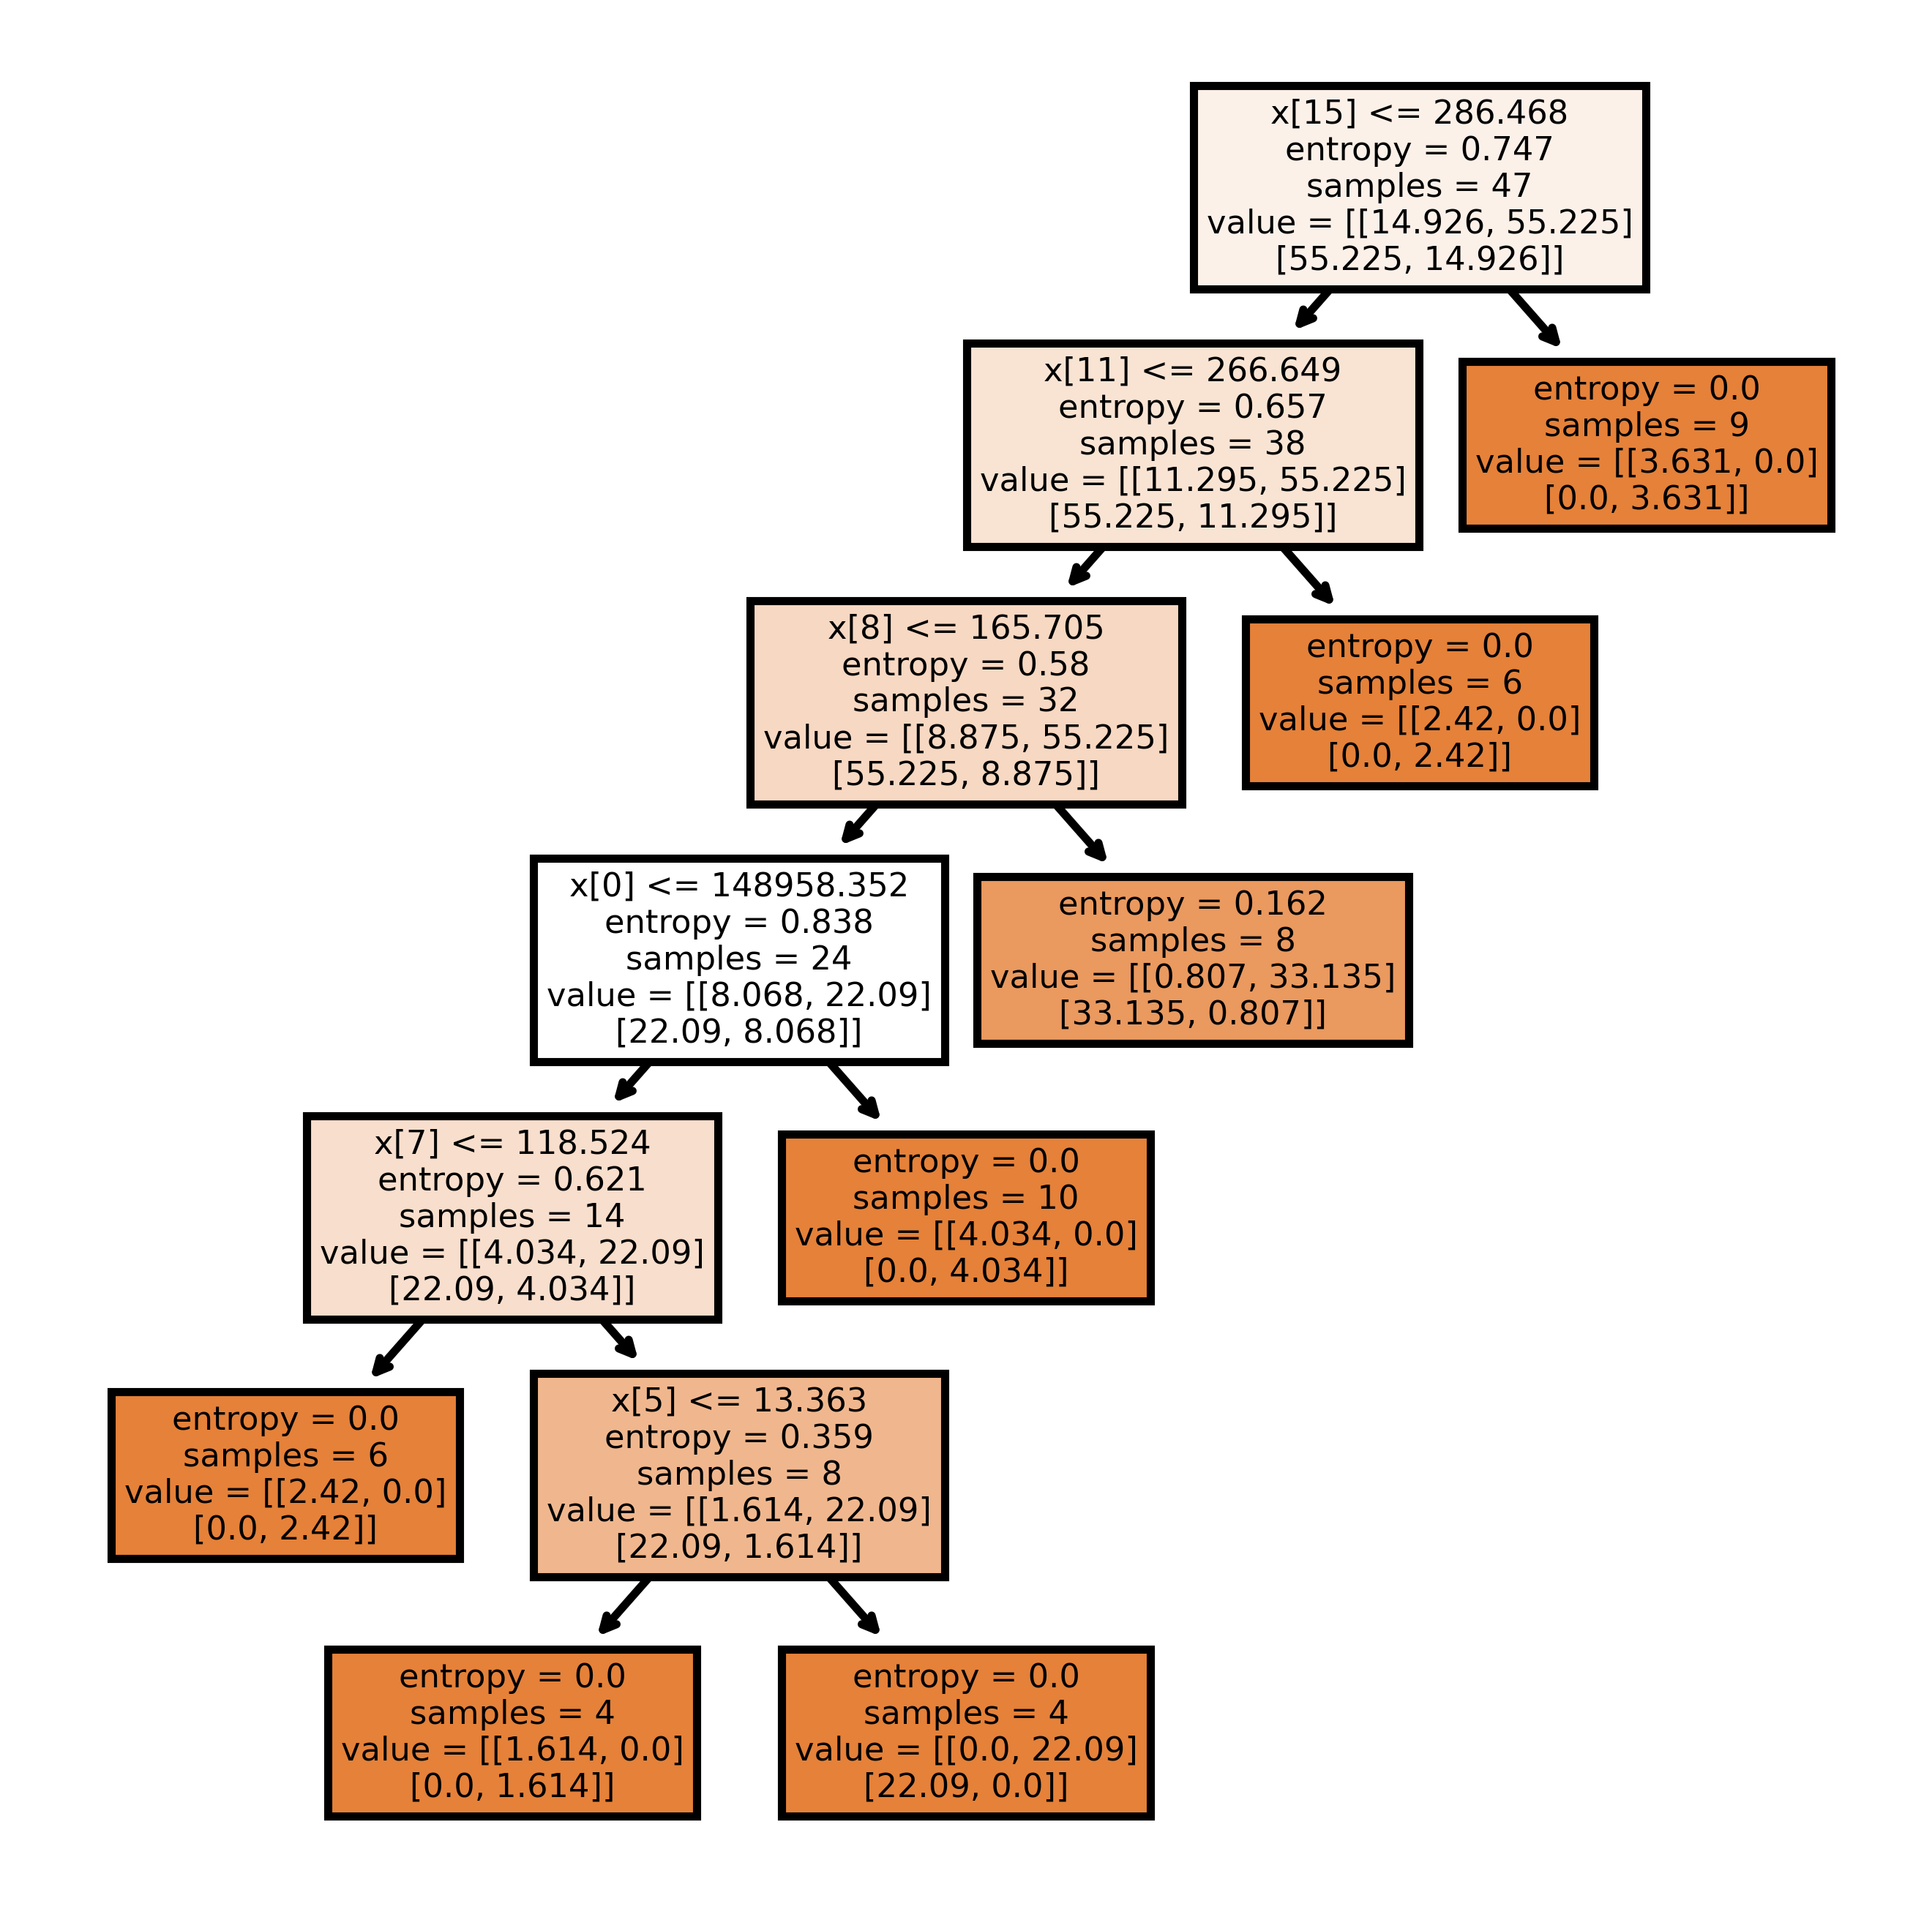

Accuracy: 43.75 %


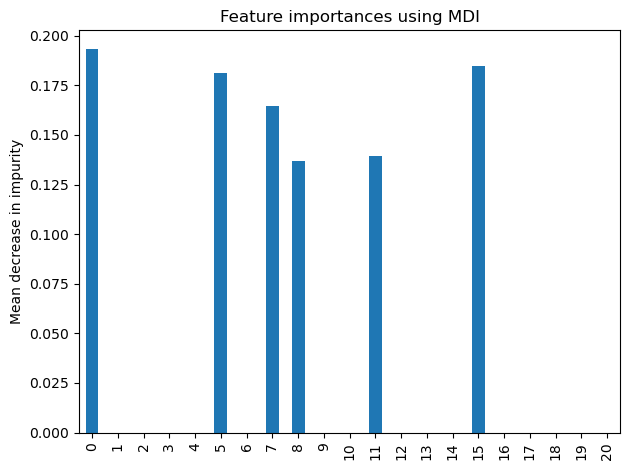

----------------------------------------------------------------------------------------------------------------------------------------


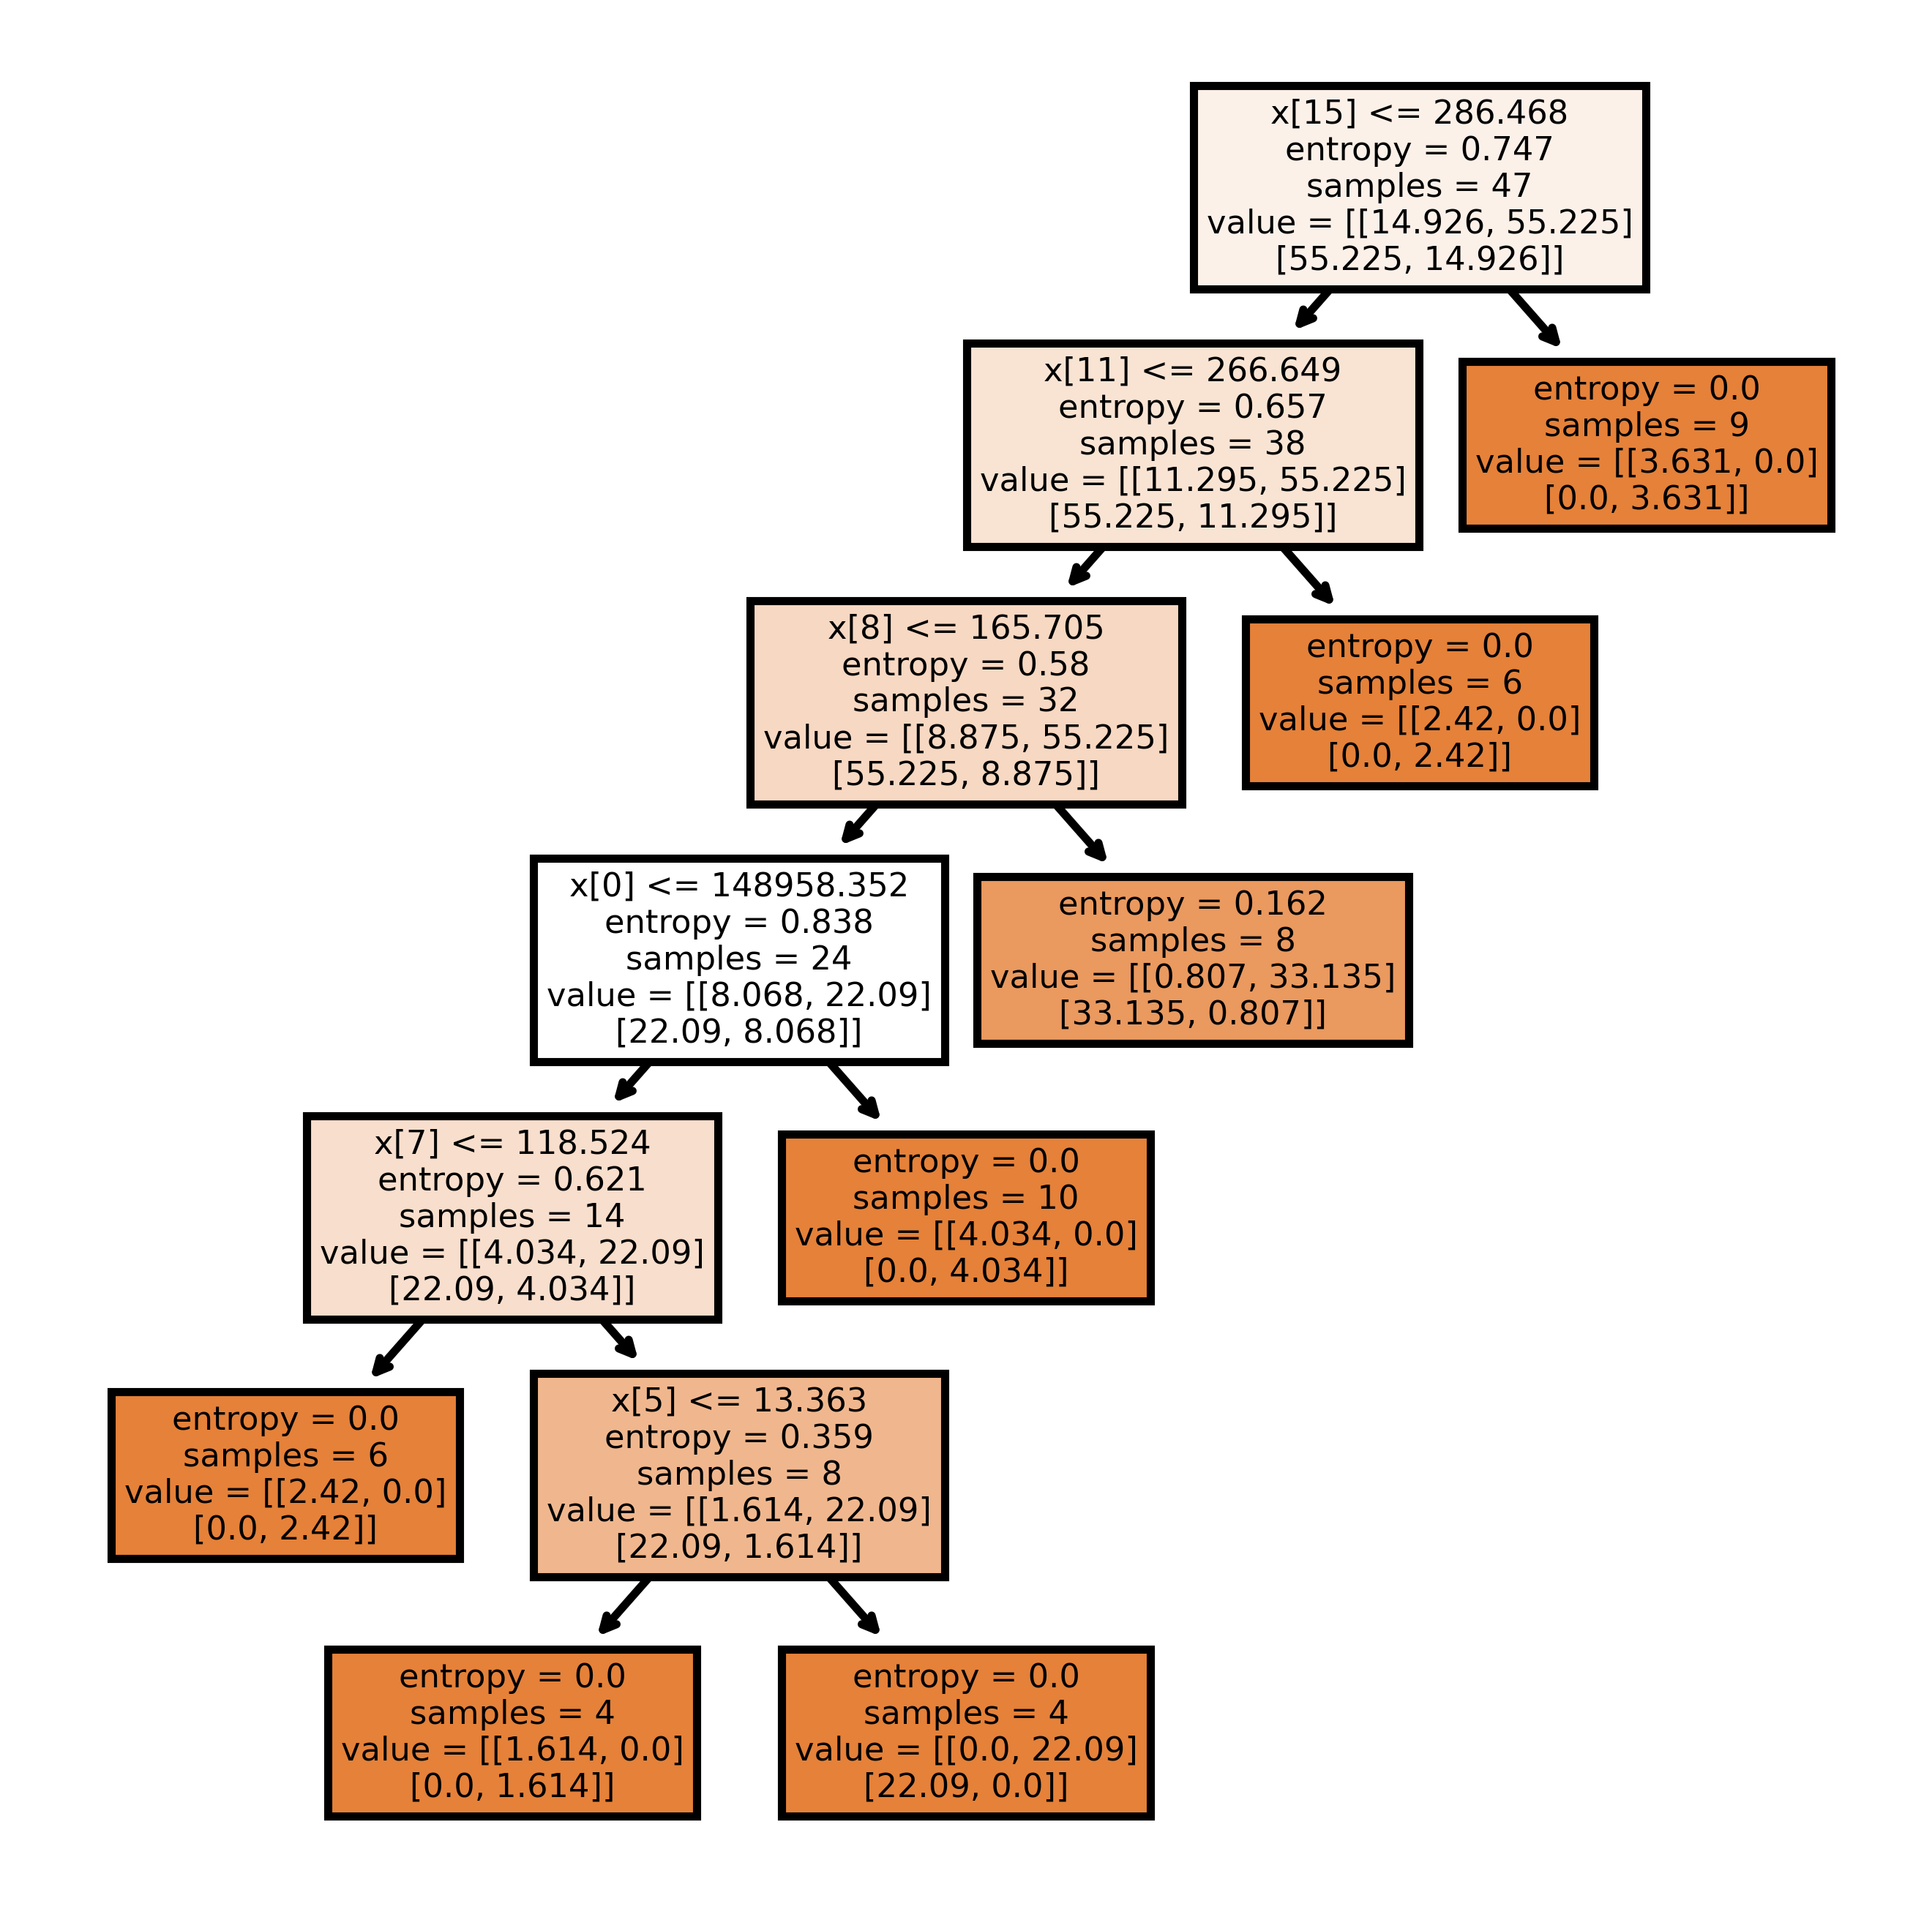

Accuracy: 95.74468085106383 %
              precision    recall  f1-score   support

     healing       0.83      1.00      0.91        10
 Not-healing       1.00      0.95      0.97        37

   micro avg       0.96      0.96      0.96        47
   macro avg       0.92      0.97      0.94        47
weighted avg       0.96      0.96      0.96        47
 samples avg       0.96      0.96      0.96        47



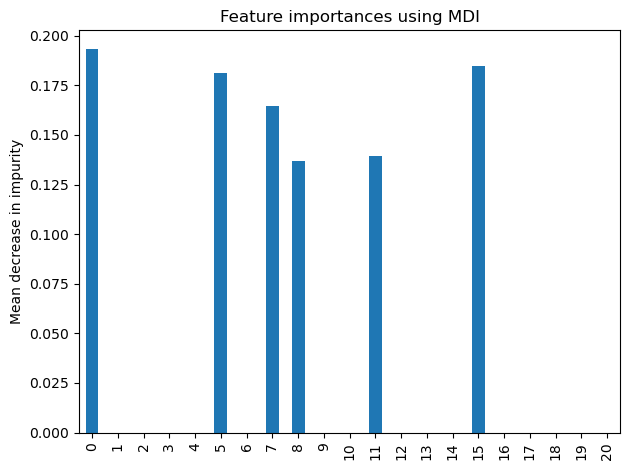

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer


Treatment=pd.read_csv("../dissertation/correlation data.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit(df_x)
df_x=imp.transform(df_x)



R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=9
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.07, random_state=R_state,stratify=df_y)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print(X_test)
print(y_test)






#names=["V2 M1","V2 M1","V3 M2","V3 M2"]



clf=DecisionTreeClassifier(max_depth=None,
                            class_weight="balanced",
                               criterion="entropy",
                              ccp_alpha=0.06,
                  
    )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["healing","Not-healing"]))

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)

#tree.plot_tree(clf, filled = True,feature_names=names);
tree.plot_tree(clf, filled = True);
#plt.savefig('Tree', dpi=1200)
plt.show()

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

importances = clf.feature_importances_

#forest_importances = pd.Series(importances, index=names)
forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

print("----------------------------------------------------------------------------------------------------------------------------------------")

df_y = to_categorical(df_y)
clf.fit(df_x,df_y)
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)

#tree.plot_tree(clf, filled = True,feature_names=names);
tree.plot_tree(clf, filled = True);
#plt.savefig('Tree', dpi=1200)
plt.show()
y_pred = clf.predict(df_x)
y_pred = (y_pred > 0.5) 
accuracy = accuracy_score(df_y, y_pred)
print("Accuracy:", (accuracy*100),"%")
print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))

importances = clf.feature_importances_
#forest_importances = pd.Series(importances, index=names)
forest_importances = pd.Series(importances)
fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()